In [51]:
!pip install jiwer
!pip install tensorflow

In [52]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from IPython import display
from jiwer import wer
import kagglehub

In [53]:
import pandas as pd
import os
import re

# Define paths
path = '/kaggle/input/tiwadataset/ASR_TiwaData'
wavs_path = os.path.join(path, 'WavFiles/')
csv_path = os.path.join(path, 'Tiwa.csv')

# Read the Tiwa CSV file
tiwa_df = pd.read_csv(csv_path)
tiwa_df.columns = ['SerialNo', 'Tiwa']
tiwa_df['SerialNo'] = tiwa_df['SerialNo'].astype(str)

# Function to extract sentence number X from file name like TIW_S1_S(X)_S1.wav
def extract_serial_number(filename):
    match = re.search(r'_S\((\d+)\)_', filename)
    if match:
        return match.group(1)
    return None

# Build dataframe of all wav file names and map to text
data = []

for root, _, files in os.walk(wavs_path):
    for file in files:
        if file.endswith('.wav'):
            serial_no = extract_serial_number(file)
            if serial_no:
                text_row = tiwa_df[tiwa_df['SerialNo'] == serial_no]
                if not text_row.empty:
                    transcription = text_row.iloc[0]['Tiwa']
                    data.append((file, transcription))

# Create a DataFrame
metadata_df = pd.DataFrame(data, columns=['file_name', 'transcription'])

# View the first few entries
metadata_df.head(50)


,file_name,transcription
0,TIW_S9_S(117)_S3.wav,Khodon taklé matrik pass hongga.
1,TIW_S5_S(24)_S1.wav,Josai mai chána phoibo.
2,TIW_S2_S(217)_S1.wav,Mindai do saja de.
3,TIW_S1_S(10)_S3.wav,Khona pasi hor hngga?
4,TIW_S16_S(391)_S3.wav,Nate tigo palthing re khubo.
5,TIW_S14_S(372)_S3.wav,Khona ná indana phiyam ?
6,TIW_S12_S(3)_S1.wav,Phor pakhál khál liga.
7,TIW_S9_S(105)_S1.wav,Khup lénggang.
8,TIW_S1_S(297)_S2.wav,Tiwarawe kham pangailo tongo.
9,TIW_S11_S(161)_S2.wav,Mis aro masúne lengjái lúw.


In [54]:
split = int(len(metadata_df) * 0.90)
df_train = metadata_df[:split]
df_val = metadata_df[split:]

print(f"Training dataset size: {len(df_train)}")
print(f"Testing dataset size: {len(df_val)}")

Training dataset size: 2509
Testing dataset size: 279


In [55]:
# The set of characters accepted in the transcription.
characters = [x for x in "aábcdeéfghiíjklmnoópqrstuúvwxyz.'?-! "]
# Mapping characters to integers
char_to_num = keras.layers.StringLookup(vocabulary=characters, oov_token="")
# Mapping integers back to original characters
num_to_char = keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'á', 'b', 'c', 'd', 'e', 'é', 'f', 'g', 'h', 'i', 'í', 'j', 'k', 'l', 'm', 'n', 'o', 'ó', 'p', 'q', 'r', 's', 't', 'u', 'ú', 'v', 'w', 'x', 'y', 'z', '.', "'", '?', '-', '!', ' '] (size =38)


In [56]:
# An integer scalar Tensor. The window length in samples.
frame_length = 256
# An integer scalar Tensor. The number of samples to step.
frame_step = 160
# An integer scalar Tensor. The size of the FFT to apply.
fft_length = 384


def encode_single_sample(wav_file, label):

    
    ##  Process the Audio
    # 1. Read wav file
    file = tf.io.read_file(wavs_path + wav_file)
    # 2. Decode the wav file
    audio, _ = tf.audio.decode_wav(file)
    audio = tf.squeeze(audio, axis=-1)
    # 3. Change type to float
    audio = tf.cast(audio, tf.float32)
    # 4. Get the spectrogram
    spectrogram = tf.signal.stft(
        audio, frame_length=frame_length, frame_step=frame_step, fft_length=fft_length
    )
    # 5. We only need the magnitude, which can be derived by applying tf.abs
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.math.pow(spectrogram, 0.5)
    # 6. normalisation
    means = tf.math.reduce_mean(spectrogram, 1, keepdims=True)
    stddevs = tf.math.reduce_std(spectrogram, 1, keepdims=True)
    spectrogram = (spectrogram - means) / (stddevs + 1e-10)

    
    ##  Process the label
    # 7. Convert label to Lower case
    label = tf.strings.lower(label)
    # 8. Split the label
    label = tf.strings.unicode_split(label, input_encoding="UTF-8")
    # 9. Map the characters in label to numbers
    label = char_to_num(label)
    # 10. Return a dict as our model is expecting two inputs
    return spectrogram, label

In [57]:
batch_size = 16
# Define the training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (list(df_train["file_name"]), list(df_train["transcription"]))
)
train_dataset = (
    train_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

# Define the validation dataset
validation_dataset = tf.data.Dataset.from_tensor_slices(
    (list(df_val["file_name"]), list(df_val["transcription"]))
)
validation_dataset = (
    validation_dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(batch_size)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

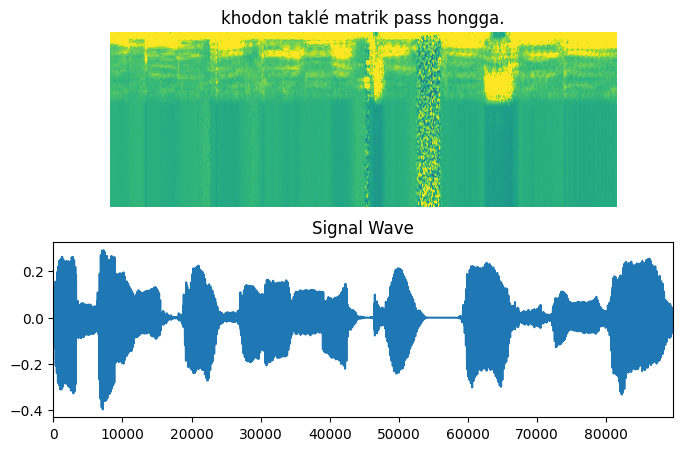

In [58]:
fig = plt.figure(figsize=(8, 5))
for batch in train_dataset.take(1):
    spectrogram = batch[0][0].numpy()
    spectrogram = np.array([np.trim_zeros(x) for x in np.transpose(spectrogram)])
    label = batch[1][0]
    # Spectrogram
    label = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
    ax = plt.subplot(2, 1, 1)
    ax.imshow(spectrogram, vmax=1)
    ax.set_title(label)
    ax.axis("off")
    # Wav
    file = tf.io.read_file(wavs_path + list(df_train["file_name"])[0])
    audio, _ = tf.audio.decode_wav(file)
    audio = audio.numpy()
    ax = plt.subplot(2, 1, 2)
    plt.plot(audio)
    ax.set_title("Signal Wave")
    ax.set_xlim(0, len(audio))
    display.display(display.Audio(np.transpose(audio), rate=33000))
plt.show()

In [59]:
def CTCLoss(y_true, y_pred):
    # Compute the training-time loss value
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [61]:
def build_model(input_dim, output_dim, rnn_layers=5, rnn_units=128):
    """Model similar to DeepSpeech2."""
    # Model's input
    input_spectrogram = layers.Input((None, input_dim), name="input")
    # Expand the dimension to use 2D CNN.
    x = layers.Reshape((-1, input_dim, 1), name="expand_dim")(input_spectrogram)
    # Convolution layer 1
    x = layers.Conv2D(
        filters=32,
        kernel_size=[11, 41],
        strides=[2, 2],
        padding="same",
        use_bias=False,
        name="conv_1",
    )(x)
    x = layers.BatchNormalization(name="conv_1_bn")(x)
    x = layers.ReLU(name="conv_1_relu")(x)
    # Convolution layer 2
    x = layers.Conv2D(
        filters=32,
        kernel_size=[11, 21],
        strides=[1, 2],
        padding="same",
        use_bias=False,
        name="conv_2",
    )(x)
    x = layers.BatchNormalization(name="conv_2_bn")(x)
    x = layers.ReLU(name="conv_2_relu")(x)
    # Reshape the resulted volume to feed the RNNs layers
    x = layers.Reshape((-1, x.shape[-2] * x.shape[-1]))(x)
    # RNN layers
    for i in range(1, rnn_layers + 1):
        recurrent = layers.GRU(
            units=rnn_units,
            activation="tanh",
            recurrent_activation="sigmoid",
            use_bias=True,
            return_sequences=True,
            reset_after=True,
            name=f"gru_{i}",
        )
        x = layers.Bidirectional(
            recurrent, name=f"bidirectional_{i}", merge_mode="concat"
        )(x)
        if i < rnn_layers:
            x = layers.Dropout(rate=0.5)(x)
    # Dense layer
    x = layers.Dense(units=rnn_units * 2, name="dense_1")(x)
    x = layers.ReLU(name="dense_1_relu")(x)
    x = layers.Dropout(rate=0.5)(x)
    # Classification layer
    output = layers.Dense(units=output_dim + 1, activation="softmax")(x)
    # Model
    model = keras.Model(input_spectrogram, output, name="DeepSpeech_2")
    # Optimizer
    opt = keras.optimizers.Adam(learning_rate=1e-4)
    # Compile the model and return
    model.compile(optimizer=opt, loss=CTCLoss)
    return model


# Get the model
model = build_model(
    input_dim=fft_length // 2 + 1,
    output_dim=char_to_num.vocabulary_size(),
    rnn_units=512,
)
model.summary(line_length=110)

Model: "DeepSpeech_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                             │ (None, None, 193)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ expand_dim (Reshape)                           │ (None, None, 193, 1)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1 (Conv2D)                                │ (None, None, 97, 32)                │              14,432 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1_bn (BatchNormalization)                 │ (None, None, 97, 32)                │                 128 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_1_relu (ReLU)                             │ (None, None, 97, 32)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2 (Conv2D)                                │ (None, None, 49, 32)                │             236,544 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2_bn (BatchNormalization)                 │ (None, None, 49, 32)                │                 128 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv_2_relu (ReLU)                             │ (None, None, 49, 32)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ reshape_2 (Reshape)                            │ (None, None, 1568)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_1 (Bidirectional)                │ (None, None, 1024)                  │           6,395,904 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_10 (Dropout)                           │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_2 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_11 (Dropout)                           │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_3 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_12 (Dropout)                           │ (None, None, 1024)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ bidirectional_4 (Bidirectional)                │ (None, None, 1024)                  │           4,724,736 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ dropout_13 (Dropout)                           │ (None, None, 1024)                  │                   0 │
├───

 Total params: 26,635,655 (101.61 MB)

 Trainable params: 26,635,527 (101.61 MB)

 Non-trainable params: 128 (512.00 B)

In [62]:
# A utility function to decode the output of the network
def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search
    results = keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    # Iterate over the results and get back the text
    output_text = []
    for result in results:
        result = tf.strings.reduce_join(num_to_char(result)).numpy().decode("utf-8")
        output_text.append(result)
    return output_text


# A callback class to output a few transcriptions during training
class CallbackEval(keras.callbacks.Callback):
    """Displays a batch of outputs and tracks WER after every epoch."""

    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset
        self.wer_history = []  # Store WER for each epoch

    def on_epoch_end(self, epoch: int, logs=None):
        predictions = []
        targets = []
        for batch in self.dataset:
            X, y = batch
            batch_predictions = model.predict(X)
            batch_predictions = decode_batch_predictions(batch_predictions)
            predictions.extend(batch_predictions)
            for label in y:
                label = (
                    tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
                )
                targets.append(label)
        wer_score = wer(targets, predictions)
        self.wer_history.append(wer_score)  # Save WER for this epoch
        print("-" * 100)
        print(f"Word Error Rate: {wer_score:.4f}")
        print("-" * 100)
        for i in np.random.randint(0, len(predictions), 2):
            print(f"Target    : {targets[i]}")
            print(f"Prediction: {predictions[i]}")
            print("-" * 100)

# Define the number of epochs
epochs = 100

# Callback function to check transcription on the validation set and track WER
validation_callback = CallbackEval(validation_dataset)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[validation_callback],
)

In [66]:
from tensorflow.keras.backend import ctc_batch_cost

# OR if you defined a custom class or function for loss
def custom_ctc_loss(y_true, y_pred):
    # your loss logic
    return ctc_batch_cost(y_true, y_pred)

model = tf.keras.models.load_model(
    '/kaggle/working/my_TiwaModel.h5',
    custom_objects={'custom_ctc_loss': custom_ctc_loss},
    compile=False  # optionally skip compiling if you want to compile manually
)


In [67]:
from jiwer import cer
predictions = []
targets = []

for batch in validation_dataset:
    X, y = batch
    batch_predictions = model.predict(X)
    batch_predictions = decode_batch_predictions(batch_predictions)
    predictions.extend(batch_predictions)
    for label in y:
        label = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")
        targets.append(label)

cer_score = cer(targets, predictions)

print("-" * 100)
print(f"Character Error Rate: {cer_score:.4f}")
print("-" * 100)

for i in np.random.randint(0, len(predictions), 5):
    print(f"Target : {targets[i]}")
    print(f"Prediction: {predictions[i]}")
    print("-" * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
----------------------------------------------------------------------------------------------------
Character Error Rate: 0.0862
----------------------------------------------------------------------------------------------------
Target : dostha bajiw shangdo.
Prediction: dostha bajiw shongdo.
-----------

dict_keys(['loss', 'val_loss'])


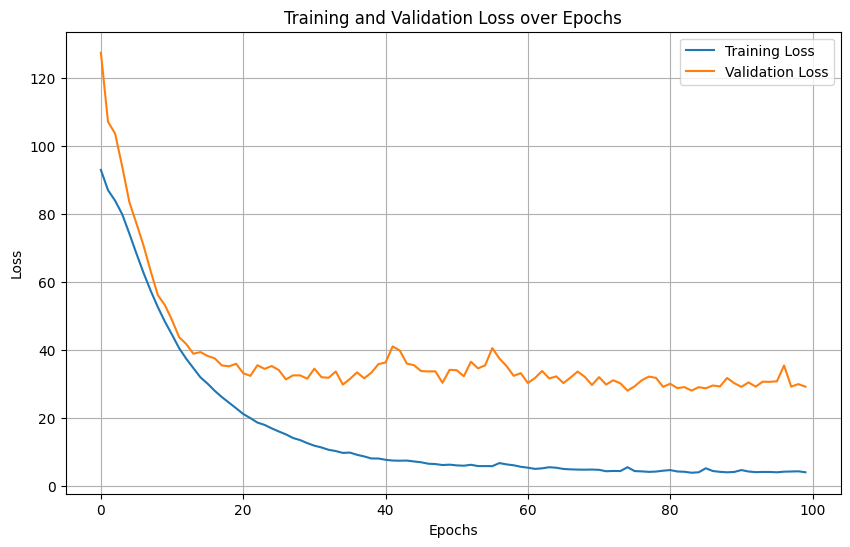

In [68]:
# Assuming 'history' is the history object from the model training
# To check what keys are available (such as 'loss', 'val_loss', 'accuracy', 'val_accuracy', etc.)
print(history.history.keys())

# Plotting Training and Validation Loss
plt.figure(figsize=(10, 6))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# If you also have accuracy values, plot them as well
# Uncomment the lines below if accuracy is available in the history
# plt.plot(history.history['accuracy'], label='Training Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

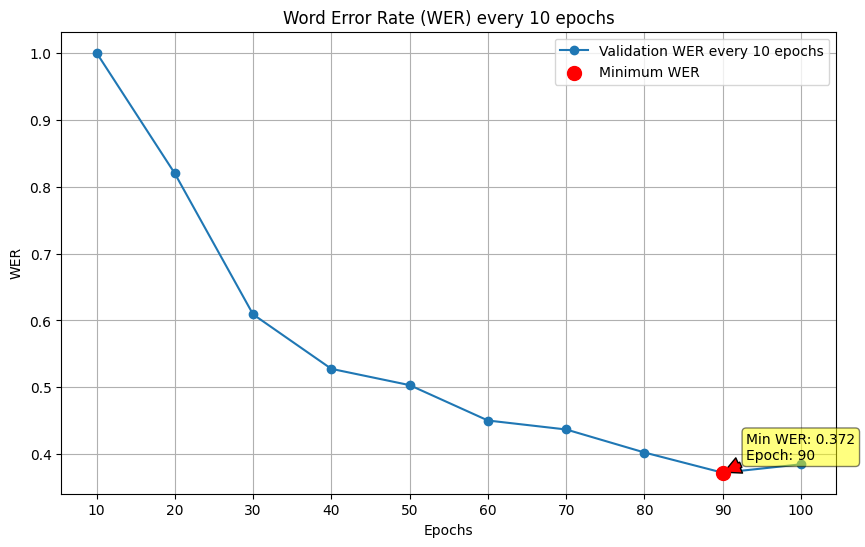

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

wer_history = validation_callback.wer_history

epochs_to_plot = list(range(10, len(wer_history) + 1, 10))
wer_to_plot = [wer_history[i - 1] for i in epochs_to_plot]

plt.plot(epochs_to_plot, wer_to_plot, marker='o', label='Validation WER every 10 epochs')

#Find minimum WER and corresponding epoch (consider only the plotted points)
min_wer = min(wer_to_plot)
min_epoch = epochs_to_plot[wer_to_plot.index(min_wer)]

#Mark the minimum WER on the plot
plt.scatter(min_epoch, min_wer, color='red', s=100, zorder=5, label='Minimum WER')

#Annotate the minimum WER
plt.annotate(f'Min WER: {min_wer:.3f}\nEpoch: {min_epoch}',
xy=(min_epoch, min_wer),
xytext=(min_epoch + 3, min_wer + 0.02),
arrowprops=dict(facecolor='red', shrink=0.05),
fontsize=10,
bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.title('Word Error Rate (WER) every 10 epochs')
plt.xlabel('Epochs')
plt.ylabel('WER')
plt.xticks(epochs_to_plot)
plt.legend()
plt.grid(True)
plt.show()

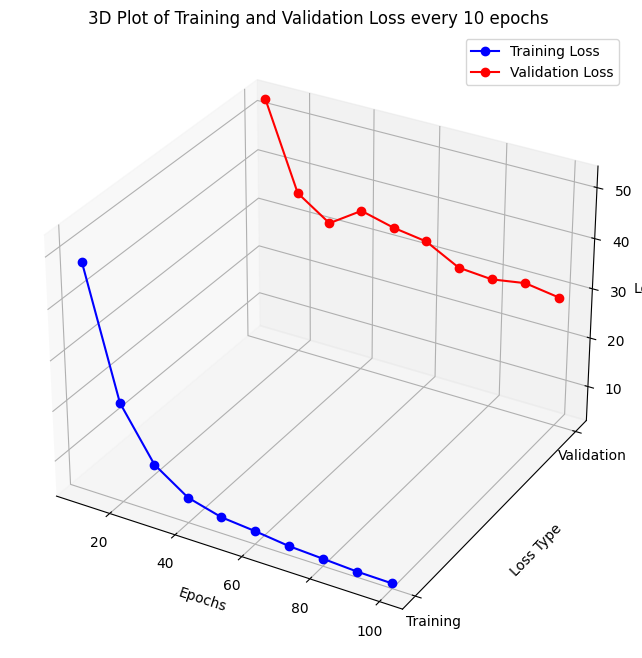

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Assuming 'history' is the history object from model training
all_epochs = np.arange(1, len(history.history['loss']) + 1)
train_loss_all = history.history['loss']
val_loss_all = history.history['val_loss']

#Select every 10th epoch
epochs = all_epochs[9::10] # zero-indexed, so 9 means epoch 10
train_loss = np.array(train_loss_all)[9::10]
val_loss = np.array(val_loss_all)[9::10]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Plot Training Loss at y=0 plane
ax.plot(epochs, train_loss, zs=0, zdir='y', label='Training Loss', color='b', marker='o')

#Plot Validation Loss at y=1 plane
ax.plot(epochs, val_loss, zs=1, zdir='y', label='Validation Loss', color='r', marker='o')

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss Type') # 0 for training, 1 for validation
ax.set_zlabel('Loss')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Training', 'Validation'])

ax.set_title('3D Plot of Training and Validation Loss every 10 epochs')
ax.legend()
plt.show()

In [ ]:
model.save('/kaggle/working/my_TiwaModel.h5')